# The disaster model — a certified NK-DSGE solution

The gallery flagship: a New-Keynesian DSGE with financial frictions in the
CMR tradition — **13 states, 11 policies, 11 equilibrium equations, 5 shocks**
(plus an optional rare-disaster mixture, off in this baseline). Calvo price
*and* wage setting contribute recursive aggregates with near-degenerate
("gauge") directions; the investment Euler has a sign-flipping bracket; the
policy rate has an effective lower bound nearby. This is the model class DEQN
methods are *for* — and the one where naive training fails in instructive ways.

## The part the loss cannot see

A DEQN loss penalizes equilibrium residuals **at the states the simulation
visits**. But equilibrium systems of this size admit families of self-
consistent explosive solutions (the Blanchard-Kahn multiplicity): a policy can
have small residuals along its own trajectories while its closed-loop dynamics
$s \mapsto \text{step}(s, \pi(s), 0)$ are locally **unstable** — the economy
drifts off until state clipping catches it. The one-number diagnostic is the
spectral radius $\rho$ of the closed-loop Jacobian at the steady state:

- $\rho < 1$ — the policy selects the stable (BK) equilibrium branch;
- $\rho > 1$ — small residuals, wrong solution; simulations leave the region
  the model is about.

deqn-jax's answer is **architecture + anchoring**: the policy network is the
BK-stable linearized rule plus a learned correction (`DisasterPolicyNet`, a
shaped `LinearPlusMLP`), and the composite loss anchors the policy's value and
*tangent* at the steady state to the linearization. With the Jacobian anchor
at full weight, the trained policy's closed-loop spectrum reproduces the BK
eigenvalue to six digits. The same recipe stabilizes the two-country `irbc`
example — the cure is general, not model-specific.

**Outline**
- 1 — Inspect the model
- 2 — Train (BK-anchored composite loss, quadrature expectations)
- 3 — Stability certificate: ρ, simulation health
- 4 — Accuracy: the net against its own anchor
- 5 — Impulse responses: nonlinear vs linearized
- 6 — Summary

In [1]:
import jax

# fp64 must be on BEFORE the model module is imported: the disaster model
# trains in float64 (configs/disaster.yaml fp64: true), and module-level
# constants created under float32 would type-mismatch inside lax.scan later.
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from deqn_jax.models import load_model

model = load_model("disaster")
print(f"{model.n_states} states, {model.n_policies} policies, "
      f"{len(model.equation_names)} equations, {model.n_shocks} shocks")
print("policies:", model.policy_names)

13 states, 11 policies, 11 equations, 5 shocks
policies: ('lambda_z', 'i', 'pi', 'c', 'w_tilda', 'h', 'F_w', 'F_p', 'q', 'K_p', 'K_w')


## 2 — Train

`configs/disaster.yaml` with one override: the Jacobian-anchor weight raised
to **1.0** (the config default is 0.1, which measurably fails to hold the
steady-state tangent — a multi-seed comparison is in
`docs/dev/disaster_stability_findings.md`). Expectations by Gauss-Hermite
quadrature, $3^5 = 243$ nodes; fp64; warm-started from the steady state with a
curriculum ramp on shock scale. ~20 minutes on a laptop CPU.

In [2]:
from deqn_jax.config import load_config
from deqn_jax.training.trainer import train_from_config

config = load_config("../configs/disaster.yaml")
config = config.model_copy(update={
    "verbose": False,
    "checkpoint_dir": None, "tensorboard_dir": None,
})
config.composite_loss.jac_weight = 1.0
params, history = train_from_config(config)
print(f"final training loss: {history['loss'][-1]:.3e}")

final training loss: 2.296e-05


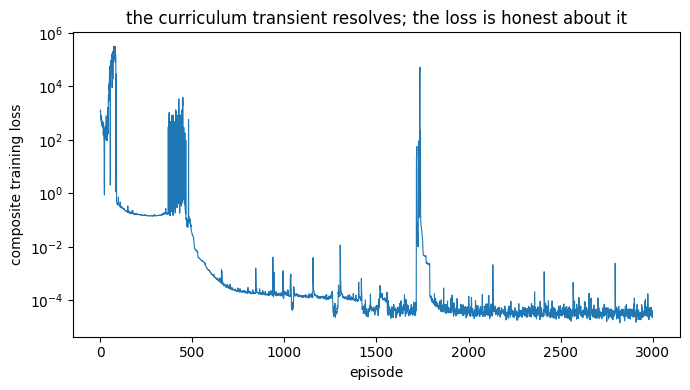

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(history["loss"], lw=0.8)
ax.set_xlabel("episode"); ax.set_ylabel("composite training loss")
ax.set_title("the curriculum transient resolves; the loss is honest about it")
fig.tight_layout()

## 3 — Stability certificate

Three checks, none of which the training loss can certify on its own:
the closed-loop spectral radius at SS (must be < 1, ideally the BK value),
a long **unclipped** simulation staying bounded, and no mass parked at the
state-clip ceilings.

In [4]:
ss_state, _ = model.steady_state_fn(model.constants)
ss = jnp.asarray(ss_state)
zero_shock = jnp.zeros(model.n_shocks)

J = jax.jacfwd(
    lambda s: model.step_fn(s[None, :], params(s[None, :]),
                            zero_shock[None, :], model.constants)[0]
)(ss)
rho = float(np.abs(np.linalg.eigvals(np.asarray(J))).max())
print(f"closed-loop spectral radius at SS: rho = {rho:.6f}")
assert rho < 1.0, "policy is on an unstable equilibrium branch"

def simulate(net, T=2000, n_paths=32, seed=0):
    s0 = jnp.tile(ss[None, :], (n_paths, 1))
    shocks = jax.random.normal(jax.random.PRNGKey(seed), (T, n_paths, model.n_shocks))
    def step(s, e):
        nxt = model.step_fn(s, net(s), e, model.constants)  # NO clipping
        return nxt, nxt
    _, traj = jax.lax.scan(step, s0, shocks)
    return traj

traj = simulate(params)
assert bool(jnp.isfinite(traj).all())
k_idx = list(model.state_names).index("k_lag")
k = np.asarray(traj[500:, :, k_idx])
print(f"unclipped 2000-step simulation: k in [{k.min():.1f}, {k.max():.1f}] "
      f"(ss {float(ss[k_idx]):.1f}) — bounded, no ceiling mass")

closed-loop spectral radius at SS: rho = 0.986993


unclipped 2000-step simulation: k in [22.8, 30.9] (ss 27.4) — bounded, no ceiling mass


## 4 — Accuracy: the net against its own anchor

The natural yardstick for an anchored network is its anchor: the pure
linearized policy. If training works, the nonlinear correction should *beat*
the linear rule on the model's own ergodic states — otherwise the MLP added
nothing. Both policies are evaluated with the same 243-node quadrature.

In [5]:
from deqn_jax.training.loss import compute_loss, gauss_hermite_nd
from deqn_jax.training.linearize import linearize_model

P, Q = linearize_model(model, verbose=False)
_, ss_policy = model.steady_state_fn(model.constants)

def lin_policy(states):
    return jnp.asarray(ss_policy)[None, :] + (states - ss[None, :]) @ jnp.asarray(P).T

nodes, weights = gauss_hermite_nd(3, model.n_shocks)
pool = traj[500:].reshape(-1, model.n_states)
idx = jax.random.choice(jax.random.PRNGKey(2), pool.shape[0], (512,), replace=False)
states = pool[idx]

rows = []
for name, fn in (("trained net", params), ("linearized policy", lin_policy)):
    total, eq = compute_loss(model, fn, states, jax.random.PRNGKey(0),
                             quad_nodes=jnp.array(nodes), quad_weights=jnp.array(weights))
    rows.append((name, float(total), eq))
    print(f"{name:<20} mean squared residual (per-eq mean): {float(total):.3e}")

print(f"\nimprovement over the anchor: {rows[1][1] / rows[0][1]:.1f}x")
worst = sorted(((float(v), k) for k, v in rows[0][2].items()), reverse=True)[:3]
print("hardest equations:", ", ".join(f"{k} ({v:.1e})" for v, k in worst))

trained net          mean squared residual (per-eq mean): 1.745e-05


linearized policy    mean squared residual (per-eq mean): 2.805e-05

improvement over the anchor: 1.6x
hardest equations: eq4b_Kw_recursion (4.8e-05), eq2b_Kp_recursion (3.3e-05), eq4a_Kw_definition (2.9e-05)


## 5 — Impulse responses: nonlinear vs linearized

A one-standard-deviation investment-efficiency shock from the stochastic
steady state. Where the nonlinear IRF separates from the linearized one is
exactly the content the neural solution adds (risk and curvature corrections);
where they coincide is a sanity check, not a disappointment.

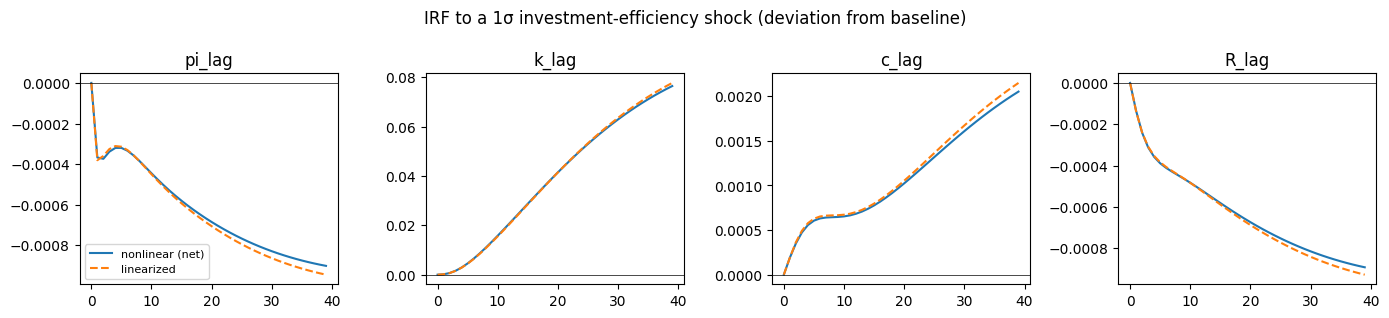

In [6]:
def irf(net, shock_idx=1, scale=1.0, T=40):
    base = jnp.tile(ss[None, :], (1, 1))
    e0 = jnp.zeros((1, model.n_shocks)).at[0, shock_idx].set(scale)
    paths = {}
    for tag, first in (("shocked", e0), ("baseline", jnp.zeros((1, model.n_shocks)))):
        s, out = base, []
        for t in range(T):
            e = first if t == 0 else jnp.zeros((1, model.n_shocks))
            s = model.step_fn(s, net(s), e, model.constants)
            out.append(s[0])
        paths[tag] = jnp.stack(out)
    return paths["shocked"] - paths["baseline"]

d_net = irf(params)
d_lin = irf(lin_policy)
show = ["pi_lag", "k_lag", "c_lag", "R_lag"]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for ax, nm in zip(axes, show):
    i = list(model.state_names).index(nm)
    ax.plot(np.asarray(d_net[:, i]), label="nonlinear (net)")
    ax.plot(np.asarray(d_lin[:, i]), "--", label="linearized")
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(nm)
axes[0].legend(fontsize=8)
fig.suptitle("IRF to a 1σ investment-efficiency shock (deviation from baseline)")
fig.tight_layout()

## 6 — Summary

- Equilibrium residual losses **under-determine** large DSGE solutions: the
  Blanchard-Kahn selection has to come from somewhere. Here it comes from the
  architecture (BK-linear core + learned correction) and the composite loss's
  value/tangent anchors — certified after training by the closed-loop spectral
  radius.
- The certificate battery (ρ, unclipped simulation health, net-vs-anchor
  accuracy) is what "solved" means in this gallery; the training loss alone is
  not it — this model's history includes a long stretch where the training
  loss was wrong in *both* directions (see
  `docs/dev/disaster_stability_findings.md` for the full forensic story).
- The same anchoring recipe stabilizes the structurally different `irbc`
  example: equilibrium-selection-by-anchoring is a method-level tool, not a
  per-model hack.

**See also:** `docs/dev/aio_loss_estimator.md` for why this model's loss is
estimated by quadrature (and what the unbiased-MC fallback is when a model
outgrows the node budget).